In [1]:
from fastai.vision.all import *

## Approch 1

- Use CNN to classify fall or not fall
- The classical way

In [2]:
from pathlib import Path
import os 
from make import load_primary_data, load_test_data

spec, labels = load_primary_data()
valid_spec, valid_labels = load_test_data()


Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 3 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Gene

In [3]:
len(spec)

1200

In [4]:
len(labels)

1200

In [5]:
len(valid_labels)

408

In [6]:
len(labels)

1200

In [7]:
print(f'Initial shape of a spectrogram: ', spec[0].shape)

ch, freq_bins = spec[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')

Initial shape of a spectrogram:  (33, 128)
Final shape: (33, 36)


In [44]:
# constants you can tweak once
FLOOR_DB   = -45.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [45]:
import matplotlib.pyplot as plt
import torch

def get_x(i):
    arr = spec[i]

    # If spectrogram is multi-channel, convert to single channel
    if arr.ndim == 3:
        arr = np.mean(arr, axis=-1)  # (H, W)

    # Ensure float32
    arr = arr.astype(np.float32)

    # If not already in dB, convert. If it *is* already in dB, skip this block.
    #arr = np.maximum(arr, EPS)
    #arr_db = 10.0 * np.log10(arr)

    # Apply dynamic range floor and normalize to [0,1]
    arr = arr - arr.max()
    arr = np.clip(arr, FLOOR_DB, 0.0)
    arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

    arr_01 = arr_01.astype(np.float32)

    arr_01 = arr_01 ** 0.9

    arr_01 = np.flipud(arr_01)

    cmap = plt.get_cmap('magma')
    img_rgb = cmap(arr_01)[:, :, :3]


    # Convert to tensor and make 3-channel (grayscale -> RGB-style)
    t = torch.from_numpy(img_rgb)          # (H, W)
    t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

    # Add batch dimension for interpolate
    #t = t.unsqueeze(0)                    # (1, 3, H, W)

    # Resize
    t_resized = F.interpolate(
        t, size=TARGET_HW, mode='bilinear', align_corners=False
    )

    # Remove batch dimension, wrap as TensorImage
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return labels[i]

In [46]:
from plot_util import PlotUtil
from tourch_util import TorchUtil

tu = TorchUtil(all_spectrograms=spec, 
               all_labels=labels, 
               TARGET_CH=TARGET_CH, 
               EPS=EPS, 
               FLOOR_DB=FLOOR_DB, 
               TARGET_HW=TARGET_HW)

In [47]:
type(spec[4])

numpy.ndarray

In [48]:
spec[4].shape

(33, 153)

In [49]:
from plot_util import PlotUtil

plotUtil = PlotUtil(spectrograms=spec)

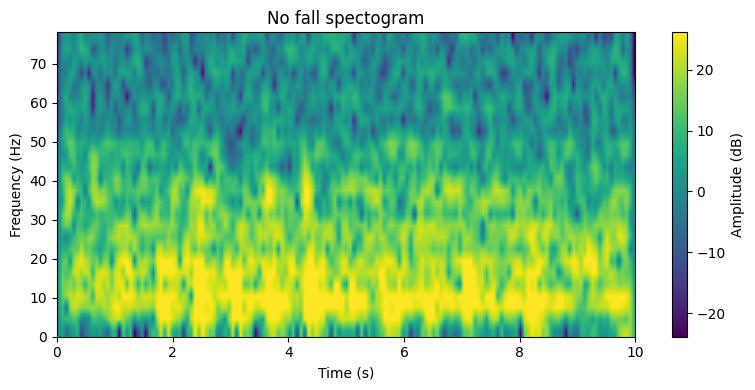

In [50]:
# Sxx_db: (F, T)
plotUtil.show_spec(4, "No fall spectogram")

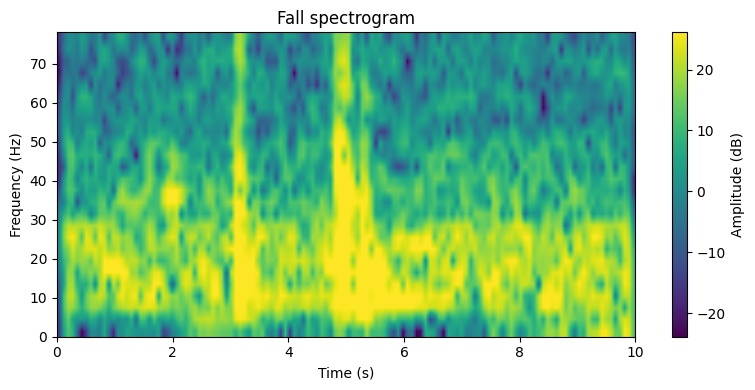

In [51]:
plotUtil.show_spec(0, "Fall spectrogram")

In [52]:
tensor_img = get_x(0)

In [53]:
get_y(4)

'Not Fall'

In [54]:
tensor_img = tu.get_x(4)

/media/Delta/code/Master/Master-project/vibration_model/tourch_util.py:20: RuntimeWarning: invalid value encountered in log10
  arr_db = 10 * np.log10(self.all_spectrograms[i])


In [55]:
import fastai


block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [56]:
items = list(range(len(spec)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

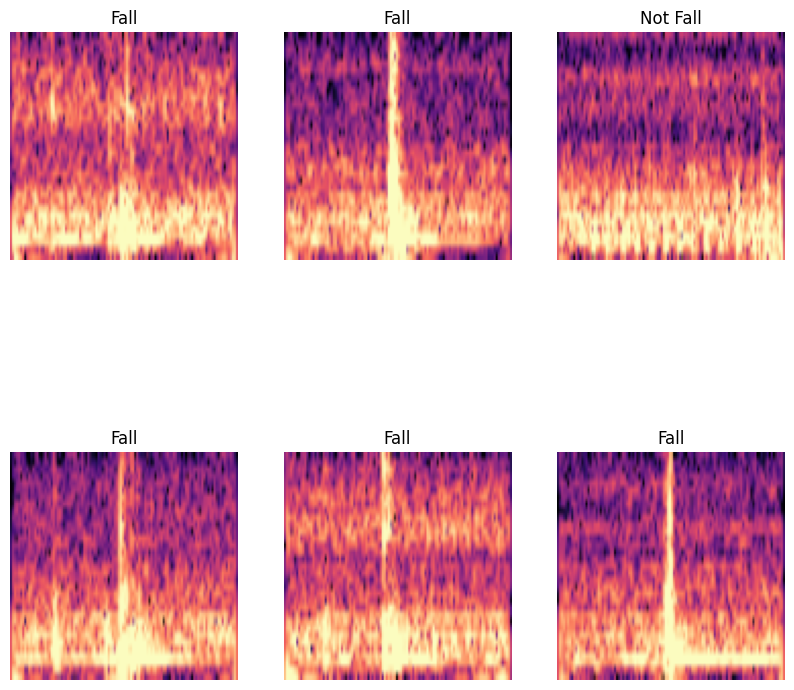

In [57]:
dls.show_batch(max_n=6, figsize=(10,10))

## Only run if you dont have a learner yet! 

epoch,train_loss,valid_loss,accuracy,time
0,0.361755,0.114913,0.937500,00:01
1,0.203040,0.190075,0.950000,00:01
2,0.151126,0.030912,0.983333,00:01
3,0.156679,0.033273,0.966667,00:01
4,0.247360,0.079392,0.962500,00:01
5,0.162062,0.022238,0.975000,00:01
6,0.127396,0.065962,1.000000,00:01
7,0.095662,0.049681,0.941667,00:01
8,0.087350,0.025186,0.975000,00:01
9,0.039731,0.041515,0.962500,00:01


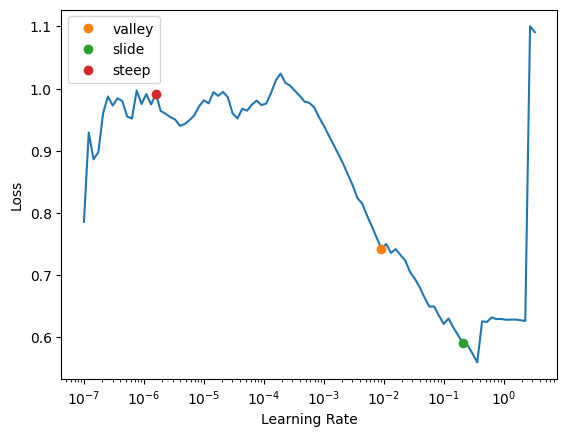

In [58]:
learner = vision_learner(dls, resnet18, metrics=accuracy, loss_func=CrossEntropyLossFlat())
learner.model[-1] = nn.Sequential(learner.model[-1], nn.ReLU())
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))
learner.fit_one_cycle(15, lr.valley)

In [59]:
learner.summary()

Sequential (Input shape: 12 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     12 x 64 x 56 x 56   
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     12 x 64 x 28 x 28   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

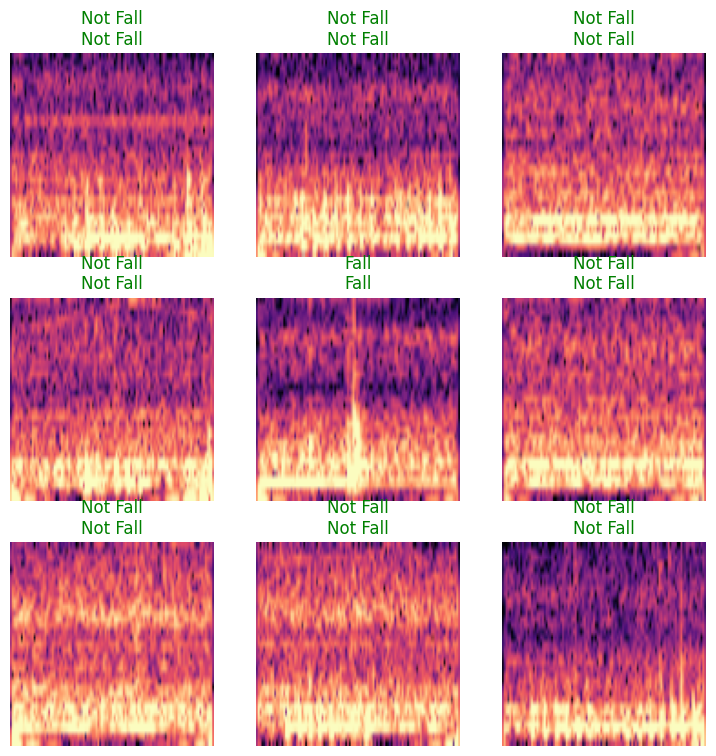

In [60]:
learner.show_results()

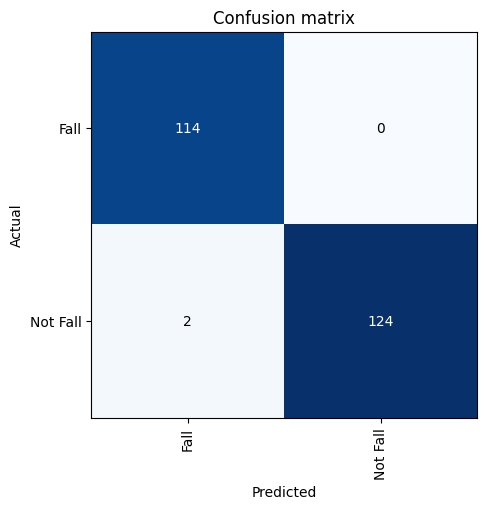

In [61]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [27]:
if not learner:
    learner = load_learner('./models/autoencoder.pkl')

In [62]:
def get_x_test(i):
    arr = valid_spec[i]
    # If spectrogram is multi-channel, convert to single channel
    if arr.ndim == 3:
        arr = np.mean(arr, axis=-1)  # (H, W)

    # Ensure float32
    arr = arr.astype(np.float32)

    # If not already in dB, convert. If it *is* already in dB, skip this block.
    #arr = np.maximum(arr, EPS)
    #arr_db = 10.0 * np.log10(arr)

    # Apply dynamic range floor and normalize to [0,1]
    arr = arr - arr.max()
    arr = np.clip(arr, FLOOR_DB, 0.0)
    arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

    arr_01 = arr_01.astype(np.float32)

    arr_01 = arr_01 ** 0.9

    arr_01 = np.flipud(arr_01)

    cmap = plt.get_cmap('magma')
    img_rgb = cmap(arr_01)[:, :, :3]


    # Convert to tensor and make 3-channel (grayscale -> RGB-style)
    t = torch.from_numpy(img_rgb)          # (H, W)
    t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

    # Add batch dimension for interpolate
    #t = t.unsqueeze(0)                    # (1, 3, H, W)

    # Resize
    t_resized = F.interpolate(
        t, size=TARGET_HW, mode='bilinear', align_corners=False
    )

    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [63]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test 

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [65]:
y_pred, y_test = get_y_pred(learner, valid_spec)

In [66]:
learner.predict(get_x_test(4))

('Not Fall', tensor(1), tensor([3.5105e-16, 1.0000e+00]))

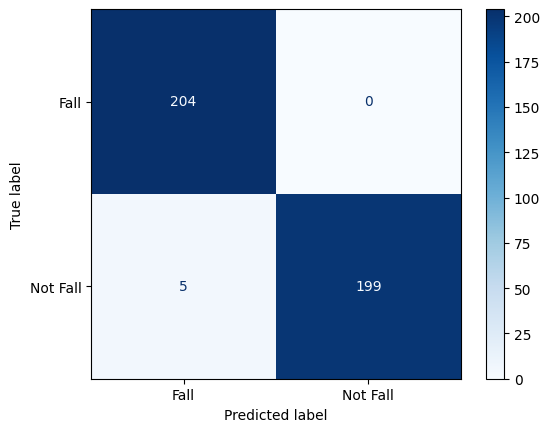

In [67]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [68]:
accuracy_score(y_test, y_pred)

0.9877450980392157

In [69]:
precision_score(y_test, y_pred, average='macro')

0.9880382775119617

In [70]:
recall_score(y_test, y_pred, average="macro")

0.9877450980392157

In [71]:
f1_score(y_test, y_pred, average="macro")

0.9877432572894573

In [72]:
dir = Path('./models')

learner.path = dir

learner.export('sd-model.pkl')